# Determine the variable features for chicken data

In [1]:
#Libraries
import os
import anndata
import pandas as pd
import numpy as np
import cESFW
import matplotlib.pyplot as plt
import umap
import warnings

/camp/home/boeziog/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Ignore warnings
warnings.filterwarnings('ignore')

In [3]:
# ─── EXPERIMENT PARAMETERS — edit these before running ───────────────────────
tissue           = "NT"       # tissue type: "NT", "meso", "SC", "full", ...
injection_stage  = "HH16"     # Hamburger-Hamilton stage at injection
collection_stage = "HH31"     # Hamburger-Hamilton stage at collection

experiment_name = f"{tissue}_inj{injection_stage}_coll{collection_stage}"
print(f"Experiment: {experiment_name}")
# ─────────────────────────────────────────────────────────────────────────────

Experiment: NT_injHH16_collHH31


## Base path to folder

In [4]:
## Set path for retreiving and depositing data
base_path = "/nemo/lab/briscoej/home/users/boeziog/LARRY/"

## Functions

In [5]:
def Feature_Weighting(ESS_Threshold, EPs_Threshold, Min_Edges, ESSs, EPs, Used_Features):
    Absolute_ESSs = np.absolute(ESSs)
    ## Network filtering
    # Initial network filtering will be done by pruning the positive EP and ESSs threshold graph until
    # all nodes of the graph have a minimum number of edges. The "OR" logic for thresholding is used
    # here because we want to exclude edges that have negative EPs or low thresholds. Essentially we are looking for a sub-graph
    # of the entire gene network where genes are connected if they show significant (EP > 0) enrichment with one another, while
    # adding heuristic ESS threshold to filter very low positive enrichments (Absolute_ESSs < ESS_Threshold).
    Mask_Inds = np.where((EPs <= EPs_Threshold) | (Absolute_ESSs < ESS_Threshold))
    ESSs_Graph = Absolute_ESSs.copy()
    ESSs_Graph[Mask_Inds] = 0
    EPs_Graph = EPs.copy()
    EPs_Graph[Mask_Inds] = 0
    ## Prune poorly connected genes
    Keep_Features = np.array([])
    while Keep_Features.shape[0] < EPs_Graph.shape[0]:
        print("Genes remaining: " + str(EPs_Graph.shape[0]))
        Keep_Features = np.where(np.sum(EPs_Graph > 0,axis=0) > Min_Edges)[0]
        Used_Features = Used_Features[Keep_Features]
        #
        Absolute_ESSs = Absolute_ESSs[np.ix_(Keep_Features,Keep_Features)]
        EPs = EPs[np.ix_(Keep_Features,Keep_Features)]
        Mask_Inds = np.where((EPs <= EPs_Threshold) | (Absolute_ESSs < ESS_Threshold))
        ESSs_Graph = Absolute_ESSs.copy()
        ESSs_Graph[Mask_Inds] = 0
        EPs_Graph = EPs.copy()
        EPs_Graph[Mask_Inds] = 0
        Keep_Features = np.where(np.sum(EPs_Graph > 0,axis=0) > Min_Edges)[0]
    ## Now we will get the weighted node centrality of each node in the graph. For this, we will use "AND" logic instead of "OR".
    # We do this because although the remaining genes meet the criteria of forming a connected graph with a minimum number of edges, some
    # gene/nodes may still have more non-significant edges than significant ones (EPs < 0) when considering all possible gene interactions,
    # meaning that the presence of these genes/nodes introduce more random noise than they contribute structure, and hence their importance
    # weights should be penalised by the negative EPs. As previously, we add a heuristic ESS threshold
    # to filter very low positive enrichments (Absolute_ESSs < ESS_Threshold).
    Mask_Inds = np.where((EPs <= EPs_Threshold) & (Absolute_ESSs < ESS_Threshold))
    Masked_ESSs = Absolute_ESSs.copy()
    Masked_ESSs[Mask_Inds] = 0
    Masked_EPs = EPs.copy()
    Masked_EPs[Mask_Inds] = 0
    ## Feature weighting via weighted node centrality
    Feature_Weights = np.average(Absolute_ESSs,weights=Masked_EPs,axis=0)
    Significant_Genes_Per_Gene = (Masked_EPs > 0).sum(1)
    Normalised_Network_Feature_Weights = Feature_Weights/Significant_Genes_Per_Gene
    return Used_Features, Absolute_ESSs, EPs, ESSs_Graph, EPs_Graph, Masked_ESSs, Masked_EPs, Feature_Weights, Normalised_Network_Feature_Weights, Significant_Genes_Per_Gene

## Read in data

In [9]:
#Read in data
file_name = f"preprocessing_larry_chicken_{experiment_name}_clean_forCESFW.h5ad"
folder_name = f"preprocessing_larry_chicken_{experiment_name}" 
file_path = os.path.join(base_path , "anndata" , file_name)
#Read in Anndata
adata = anndata.read_h5ad(file_path)

### DATASET/BATCH corrections

In [10]:
print(adata.obs.columns)

Index(['sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts',
       'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'leiden',
       'sample', 'scvi_leiden_2', 'to_remove', 'cluster_2', 'cluster_4',
       'cluster_6', 'cluster_8', 'cluster_10'],
      dtype='object')


In [11]:
## An attractive property of the cESFW workflow that we present here is that we can obtain a high resolution UMAP
# embedding without having to augment the original counts matrix through smoothing or feature extraction. Data augmentation
# is typical in many scRNA-seq pipelines, and imputation through smoothing/regression, or feature extraction through methods such as PCA,
# are applied in an attempt to mitigate the contribution of noisy signals or batch effects. However, whenever a smoothign or transformation
# is applied to complex high dimensional data, there is a substantial risk of removing feature correlations/strcuture that is informative
# of the biological process of interest. 
#
## cESFW allows us to avoid the use of smoothing/feature extraction methods by simply identifying a set of genes that are
# significantly structured with one another throughout the data. Perhaps more importnatly, this allows us to ignore the thousands
# of features/genes that are noisy and uninformative of teh biological process, which when left in the data for downstream analysis,
# obsfucate the biological signal of interest. 
# 
# However, genes that are consitently up/down-regualated in a specific batch or dataset due to experimental variation or bias, can
# also be constituted as "highly structured" with one another, and hence should be highlighted by cESFW as informative. Hence, we will
# pre-filter out genes that are significantly and specifically present/absent in a single dataset, so that they cannot manifest as batch
# effects in downstream analysis/visualisation. The assumption behind this pre-filtering is that if a gene is significantly localised to one
# dataset, it is likely a counfounding batch effect. This assumption is reliant on each individual dataset consiting of multiple distinct
# cell types. If a dataset consists almost entirely of one cell type that is not present in any of the other datasets, then biologically
# meaningful gene signatures for that cell type will also look like batch effects and be arbitraility removed.
#
## Crucially, this simple feature exclusion methodology does not require any data augmentation to acheive dataset integration.
# As such, we can be more confident that any gene expression patterns we identify downstream are real signals, rather than computational
# artefacts.

## Load the feature IDs that were saved when creating the computational efficient objects.
Used_Features = np.load(os.path.join(base_path ,  "cesfw" , folder_name ,"Used_Features.npy"),allow_pickle=True)
ESSs = np.load(os.path.join(base_path ,  "cesfw" , folder_name,"ESSs.npy"))
EPs = np.load(os.path.join(base_path ,  "cesfw" , folder_name,"EPs.npy"))

Unique_Dataset_IDs = np.unique(adata.obs["sample"])
Dataset_ESSs = np.zeros((Used_Features.shape[0],Unique_Dataset_IDs.shape[0]))
Dataset_EPs = np.zeros((Used_Features.shape[0],Unique_Dataset_IDs.shape[0]))

for i in np.arange(Unique_Dataset_IDs.shape[0]):
    Dataset_Labels = np.zeros(len(adata.obs["sample"]))
    Dataset_Labels[np.where(adata.obs["sample"]==Unique_Dataset_IDs[i])[0]] = 1
    # If the number of samples in the dataset is greater than half the cardinality of the entire data, flip the majority/minority state labels.
    if np.sum(Dataset_Labels) > (len(adata.obs["sample"])/2):
        Dataset_Labels = (Dataset_Labels * - 1) + 1
    ## Calulate the ESSs and EPs of the dataset with every feature/gene in the scaled matrix.
    Individual_ESSs, Individual_EPs = cESFW.Calculate_Individual_ESS_EPs(Dataset_Labels,(os.path.join(base_path ,  "cesfw"  , folder_name) + "/"))
    ## Create a ranked list of features the are enriched in the dataset
    Dataset_ESSs[:,i] = Individual_ESSs
    Dataset_EPs[:,i] = Individual_EPs

Dataset_ESSs = pd.DataFrame(Dataset_ESSs,columns=Unique_Dataset_IDs)
Dataset_EPs = pd.DataFrame(Dataset_EPs,columns=Unique_Dataset_IDs)

In [12]:
## We will now exclude all genes that have an EP > 0 with any of the datasets from downstream analysis,
# under the assumption that their enrichment in these datasets occours to a degree greater than random chance.
# There are obviously other criteria that one could use which may be better in different cases.

Exclude_Feature_Inds = np.where(Dataset_EPs.max(axis=1) > 0)[0]
Subset_Use_Feature_Inds = np.delete(np.arange(Used_Features.shape[0]),Exclude_Feature_Inds)

## Note which featue names remain.
Subset_Used_Features = Used_Features[Subset_Use_Feature_Inds]
Subset_Used_Inds_Features = {Used_Features[Inds] : Inds for Inds in Subset_Use_Feature_Inds}

In [13]:
## Subset Masked_ESSs to the remaining features. Masked refers to process of finding all indicies in in EPs matrix that are less than 0
# and setting the values at these indexes to zero in the ESSs or EPs matrix. This provides a mathmatically defined way to turn and dense
# correlation matrix into a sparse matrix where non-significant gene-gene correlations are ignored.
ESSs = ESSs[np.ix_(Subset_Use_Feature_Inds,Subset_Use_Feature_Inds)]
EPs = EPs[np.ix_(Subset_Use_Feature_Inds,Subset_Use_Feature_Inds)]

In [14]:
print("Subset ESSs shape:", ESSs.shape)
print("Subset EPs shape:", EPs.shape)
print("Remaining features:", len(Subset_Used_Features))

# Spot-check values
print("ESSs summary:", np.min(ESSs), np.max(ESSs), np.mean(ESSs))
print("EPs summary:", np.min(EPs), np.max(EPs), np.mean(EPs))

# Are matrices symmetric? (they should be)
print("ESSs symmetric?", np.allclose(ESSs, ESSs.T))
print("EPs symmetric?", np.allclose(EPs, EPs.T))

# Check diagonal (should be 0 for ESS/EP usually)
print("ESSs diag mean:", np.mean(np.diag(ESSs)))
print("EPs diag mean:", np.mean(np.diag(EPs)))

Subset ESSs shape: (18412, 18412)
Subset EPs shape: (18412, 18412)
Remaining features: 18412
ESSs summary: -0.18066967896903646 1.0000106194381893 0.005925926549873938
EPs summary: -1.025556564928479 0.00032301382053457093 -0.01638537122219262
ESSs symmetric? True
EPs symmetric? True
ESSs diag mean: 0.9999999774833971
EPs diag mean: 0.0


## Gene markers
These marker genes will help with the feature selection.

In [15]:
progenitor_markers = {
"Roof_plate" : ["LMX1A" , "WNT1"],
"dp1_3" : ["MSX1" , "OLIG3","PAX3" , "PAX7" ,"PAX6", "IRX3" , "IRX5"],
"dp4" : ["GSX1" , "GSX2", "ASCL1", "PTF1A", "PAX3" , "PAX7" , "PAX6" , "IRX3" , "IRX5"],
"dp5" : ["GSX1" ,"GSX2", "ASCL1", "PAX3" , "PAX7" , "PAX6" , "IRX3" , "IRX5"],
"dp6" : ["DBX2" ,"DBX1" ,"PAX3" , "PAX7" , "PAX6" , "IRX3" , "IRX5", "SP8"],
"p0" : ["DBX1" ,  "PAX6" , "IRX3" , "IRX5", "SP8"],
"p1" : ["DBX2" , "NKX6-2" , "PAX6" , "IRX3" , "IRX5", "SP8", "PRDM12"],
"p2" : ["NKX6-2" , "PAX6" , "IRX3" , "IRX5", "SP8"],
"pMN" : ["OLIG2" , "NKX6-2"],
"p3" : ["NKX2-8" , "NKX2-2" , "NKX6-2"],
"Floor_plate" : ["SHH" , "ARX" , "FOXA2"],
"cycle" : ["TOP2A", "CENPF", "CENPE"],
"OPCs" : ["SOX10", "OLIG2", "PDGFRA", "NKX2-2"],
"extra" : ["GBX2"]}

Neuron_markers_orig = {
"dI1" : ["LHX2" , "LHX9"],
"dI2" : ["LHX1" , "LHX5", "FOXD3"],
"dI3" : ["ISL1" , "TLX3" ],
"dI4" : ["LBX1" , "PAX2", "LHX1", "LHX5"],
"dI5" : ["LBX1" , "TLX3", "LMX1B"],
"dI6" : ["LBX1", "DMRT1" , "PAX2" , "LHX1" , "LHX5" , "WT1", "IRX1", "IRX2"],
"V0" : ["EVX1" , "EVX2" , "PAX2" , "LHX1" , "LHX5" ],
"V1" : ["EN1" , "PAX2" , "LHX1" , "LHX5","FOXP1", "FOXP2", "FOXD3"],
"V2" : ["VSX2" , "LHX3" , "GATA2" , "GATA3","TAL1"],
"MN" : ["MNX1" , "LHX3" , "ISL1" , "ISL2"],
"V3" : ["SIM1" , "NKX2-2", "OLIG3" ]}

In [16]:
prog_neu_merge = progenitor_markers | Neuron_markers_orig
marker_genes = list(set([marker for markers in prog_neu_merge.values() for marker in markers]))

## Perform feature selection

Genes remaining: 18412
Genes remaining: 7683
Genes remaining: 7620
Genes remaining: 7605
Genes remaining: 7599
Genes remaining: 7597


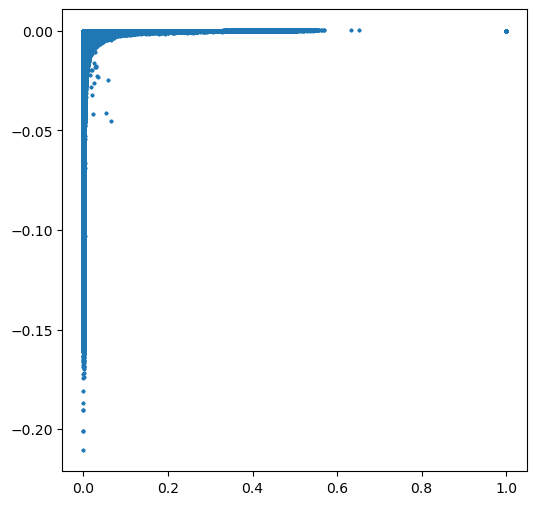

In [17]:
#Original edges
ESS_Threshold = 0.025
EPs_Threshold = 0
Min_Edges = 5

Subset_Used_Features , ESSs, EPs, ESSs_Graph, EPs_Graph, Masked_ESSs, Masked_EPs, Feature_Weights, Normalised_Network_Feature_Weights, Significant_Genes_Per_Gene = Feature_Weighting(ESS_Threshold, EPs_Threshold, Min_Edges, ESSs, EPs, Subset_Used_Features)

plt.figure(figsize=(6,6))
plt.scatter(np.ndarray.flatten(ESSs),np.ndarray.flatten(EPs),s=3)
plt.show()

In [18]:
### Feature selection importance weighting ###

# Some genes that we know are important in  NT chicken embryo development
Known_Important_Genes = np.array(marker_genes)
Known_Important_Genes[np.isin(Known_Important_Genes,Subset_Used_Features) == 0]
Known_Important_Gene_Inds = np.where(np.isin(Subset_Used_Features,Known_Important_Genes))[0]

In [19]:
## Running the next two lines shows us that genes that we know to be important for NT chick development, are amongst the highest
# ranked genes when considering the normalised network feature weights.
np.where(np.isin(np.argsort(-Feature_Weights),Known_Important_Gene_Inds))[0]
np.where(np.isin(np.argsort(-Normalised_Network_Feature_Weights),Known_Important_Gene_Inds))[0]

array([   6,   48,  116,  120,  130,  138,  219,  356,  410,  830,  854,
        895,  944, 1031, 1152, 1159, 1375, 1415, 1425, 1553, 1707, 1900,
       1915, 1923, 2004, 2077, 2206, 2268, 2583, 3085, 3203])

In [20]:
#Check different ranges of the X top CESFW genes
range_of_interest = range(500 , 3500 , 500)

In [21]:
feature_elements = {}

for feat_numb in range_of_interest:
    Use_Inds = np.argsort(-Normalised_Network_Feature_Weights)[np.arange(feat_numb)] 
    Selected_Genes = Subset_Used_Features[Use_Inds]
    feature_elements[feat_numb] = {"Use_Inds" : Use_Inds , "Selected_Genes" : Selected_Genes}

#### Gene cluster visualisation

data of interest

500


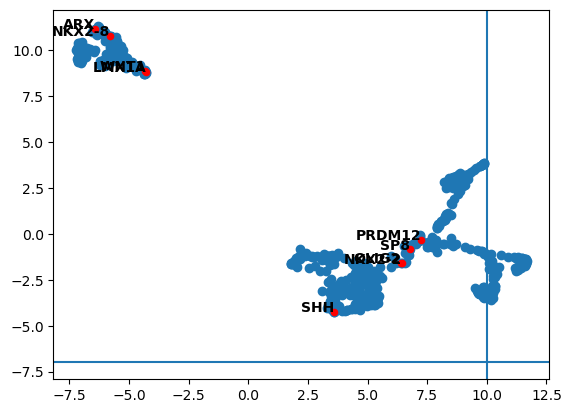

1000


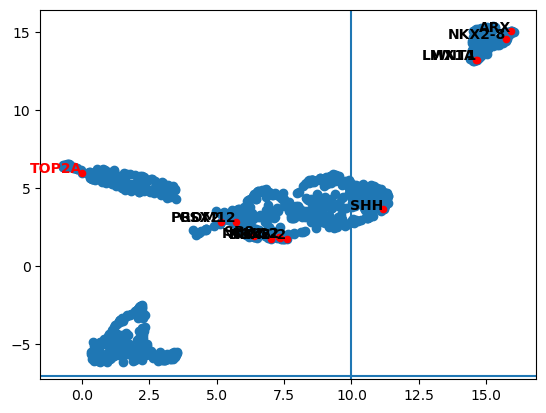

1500


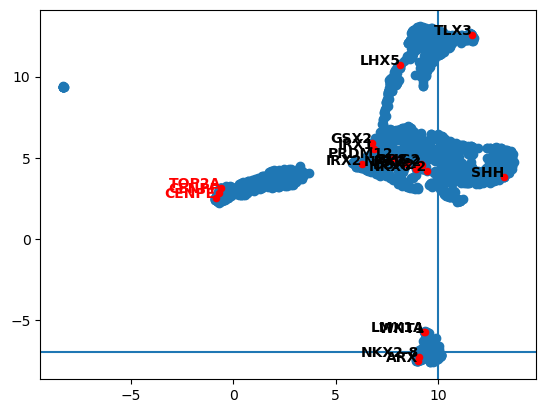

2000


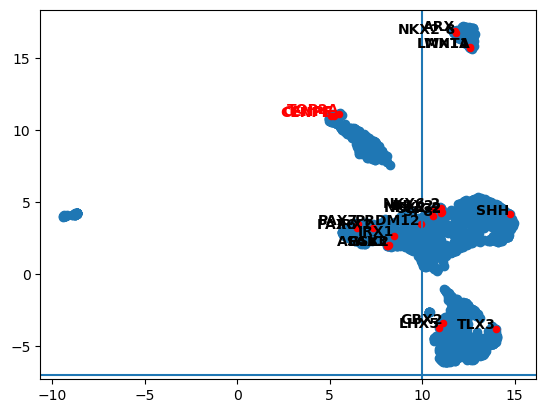

2500


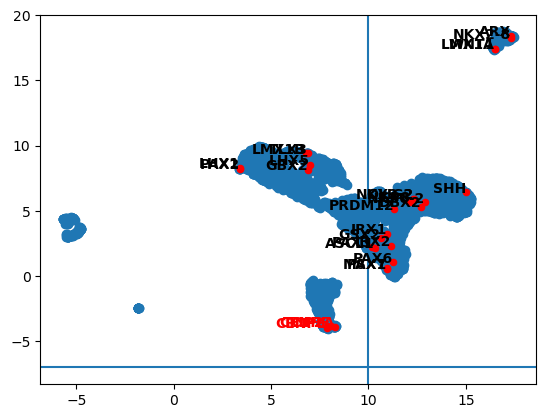

3000


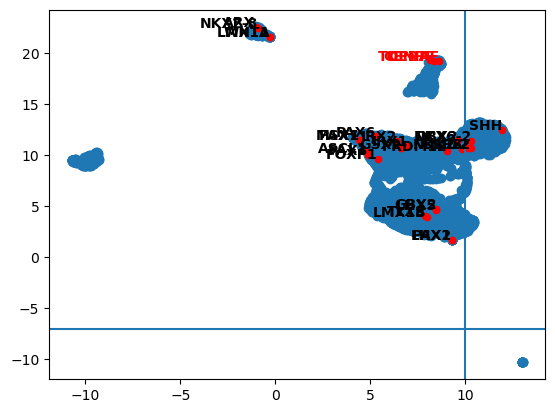

In [22]:
# Number of iterations

for number_genes in range_of_interest:
    print(number_genes)
    Use_Inds = feature_elements[number_genes]["Use_Inds"]
    Selected_Genes = feature_elements[number_genes]["Selected_Genes"]
    input_data = Masked_ESSs[np.ix_(Use_Inds,Use_Inds)]
    Neighbours = 20
    Dist = 0.1
    reducer = umap.UMAP(n_neighbors=Neighbours, min_dist=Dist, n_components=2 , random_state=42)
    output_umap = reducer.fit_transform(input_data)
    Plot_Important_Inds = np.where(np.isin(Selected_Genes,Known_Important_Genes))[0]
    #Plot_Remove_Inds = np.where(np.isin(Selected_Genes,remove_those))[0]
    
    Plt_names = np.array([ Selected_Genes[marker] for marker in Plot_Important_Inds])
    #Plt_remove_names = np.array([ Selected_Genes[marker] for marker in Plot_Remove_Inds])
    
    plt.scatter(output_umap[:,0],output_umap[:,1])
    plt.scatter(output_umap[Plot_Important_Inds,0],output_umap[Plot_Important_Inds,1],s=20,c="red")
                         
    for i , name in enumerate(Plt_names):
        position = Plot_Important_Inds[i]
        
        if name in progenitor_markers["cycle"]:
            plt.text(output_umap[position,0],output_umap[position,1], name, fontsize=10, ha='right' , weight = "bold" , c = "red")
        else:
            plt.text(output_umap[position,0],output_umap[position,1], name, fontsize=10, ha='right' , weight = "bold")  
    plt.axvline(10)
    plt.axhline(-7)
    plt.show()

In [23]:
number_genes_choice = 1500
Use_Inds = feature_elements[number_genes_choice]["Use_Inds"]
Selected_Genes = feature_elements[number_genes_choice]["Selected_Genes"]
input_data = Masked_ESSs[np.ix_(Use_Inds,Use_Inds)]
output_umap = reducer.fit_transform(input_data)

### Feature selection based on UMAP coordinates

In [24]:
# Define a window in UMAP1 (between -5 and 20) --> check your UMAP with the n genes of choice to remove uninformative clusters
bool_select = (output_umap[:,0] > -5) & (output_umap[:,0] < 20)

# Apply mask
selected_input_data = input_data[bool_select][:, bool_select]
selected_input_genes = Selected_Genes[bool_select]
selected_Use_Inds = Use_Inds[bool_select]
selected_Subset_Used_Features = Selected_Genes[bool_select]

print(f"Kept {np.sum(bool_select)} / {len(Selected_Genes)} genes")

Kept 1490 / 1500 genes


In [25]:
## Visualise the gene clusters on a UMAP.
Neighbours = 20
Dist = 0.1
Gene_Embedding = umap.UMAP(n_neighbors=Neighbours, min_dist=Dist, n_components=2 , random_state=42).fit_transform(selected_input_data)

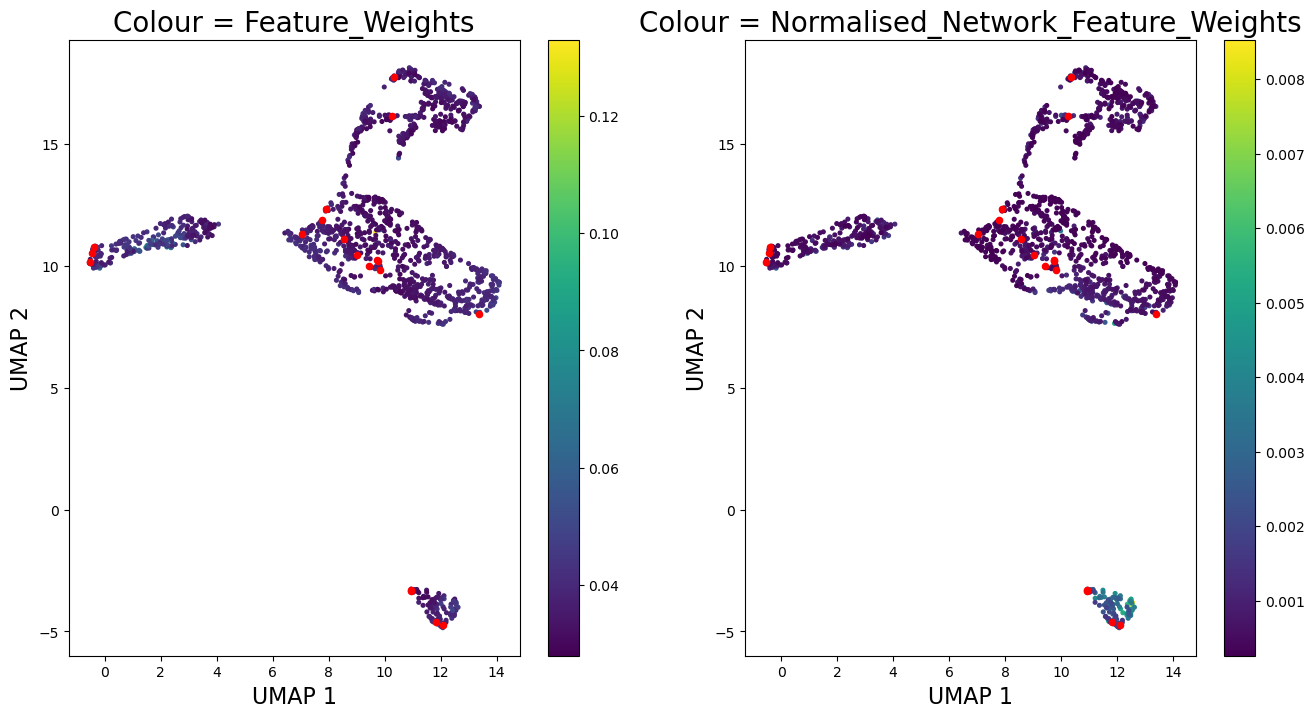

In [26]:
#Make umap based on the selected features
Plot_Important_Inds = np.where(np.isin(selected_input_genes,Known_Important_Genes))[0]
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.title("Colour = Feature_Weights", fontsize=20)
plt.scatter(Gene_Embedding[:,0],Gene_Embedding[:,1],s=7,c=Feature_Weights[selected_Use_Inds])
plt.colorbar()
plt.scatter(Gene_Embedding[Plot_Important_Inds,0],Gene_Embedding[Plot_Important_Inds,1],s=20,c="red")
plt.xlabel("UMAP 1",fontsize=16)
plt.ylabel("UMAP 2",fontsize=16)
plt.subplot(1,2,2)
plt.title("Colour = Normalised_Network_Feature_Weights", fontsize=20)
plt.scatter(Gene_Embedding[:,0],Gene_Embedding[:,1],s=7,c=Normalised_Network_Feature_Weights[selected_Use_Inds])#,vmax=0.0002)
plt.colorbar()
plt.scatter(Gene_Embedding[Plot_Important_Inds,0],Gene_Embedding[Plot_Important_Inds,1],s=20,c="red")
# plt.scatter(Gene_Embedding[:,0],Gene_Embedding[:,1],s=7,c=np.log2(Feature_Weights*Significant_Genes_Per_Gene)[Use_Inds])
plt.xlabel("UMAP 1",fontsize=16)
plt.ylabel("UMAP 2",fontsize=16)
# plt.savefig(human_embryo_path + "Gene_Cluster.png",dpi=600)
# plt.close()
plt.show()

In [27]:
# Boolean mask: keep only genes with UMAP2 (y-axis) < 12 to throw away the tiny cluster
bool_select = (Gene_Embedding[:,1] < 20) 

Gene_Embedding = Gene_Embedding[bool_select]
selected_input_data = selected_input_data[bool_select][:, bool_select]
selected_input_genes = selected_input_genes[bool_select]
selected_Use_Inds = selected_Use_Inds[bool_select]
selected_Subset_Used_Features = selected_Subset_Used_Features[bool_select]

print(f"Kept {Gene_Embedding.shape[0]} genes after filtering")

Kept 1490 genes after filtering


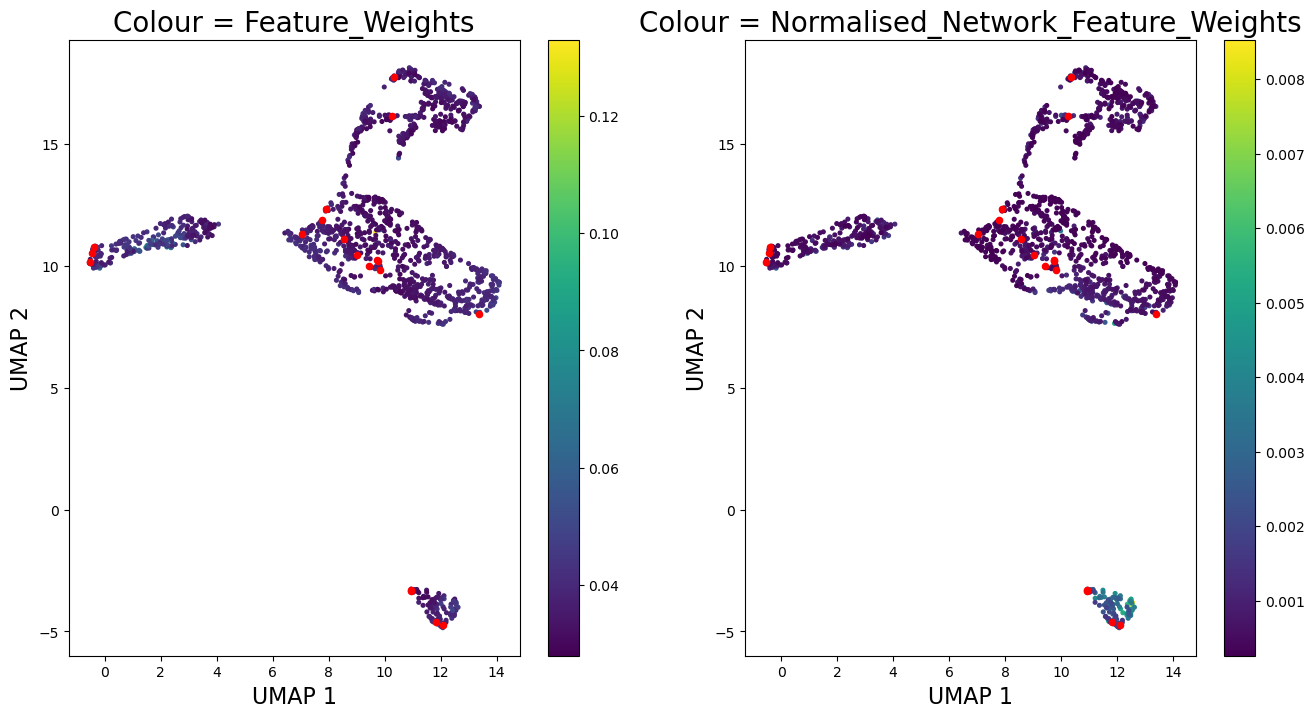

In [28]:
#Make umap based on the selected features
Plot_Important_Inds = np.where(np.isin(selected_input_genes,Known_Important_Genes))[0]
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.title("Colour = Feature_Weights", fontsize=20)
plt.scatter(Gene_Embedding[:,0],Gene_Embedding[:,1],s=7,c=Feature_Weights[selected_Use_Inds])
plt.colorbar()
plt.scatter(Gene_Embedding[Plot_Important_Inds,0],Gene_Embedding[Plot_Important_Inds,1],s=20,c="red")
plt.xlabel("UMAP 1",fontsize=16)
plt.ylabel("UMAP 2",fontsize=16)
plt.subplot(1,2,2)
plt.title("Colour = Normalised_Network_Feature_Weights", fontsize=20)
plt.scatter(Gene_Embedding[:,0],Gene_Embedding[:,1],s=7,c=Normalised_Network_Feature_Weights[selected_Use_Inds])#,vmax=0.0002)
plt.colorbar()
plt.scatter(Gene_Embedding[Plot_Important_Inds,0],Gene_Embedding[Plot_Important_Inds,1],s=20,c="red")
# plt.scatter(Gene_Embedding[:,0],Gene_Embedding[:,1],s=7,c=np.log2(Feature_Weights*Significant_Genes_Per_Gene)[Use_Inds])
plt.xlabel("UMAP 1",fontsize=16)
plt.ylabel("UMAP 2",fontsize=16)
# plt.savefig(human_embryo_path + "Gene_Cluster.png",dpi=600)
# plt.close()
plt.show()

### Save the output of the selected features

In [29]:
np.save(os.path.join(base_path , "cesfw" , folder_name , f"selected_cesfw_features_{experiment_name}.npy") , selected_input_genes)